<a href="https://colab.research.google.com/github/leonidasf300/OUU2026/blob/main/LeonSerna_OUU_project_v0_simple_feeder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple feeder to do a simple model

# Installing libraries

In [ ]:
pip install pandapower[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 13.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 15.7 MB/s eta 0:00:00
 

# Importing libraries

In [ ]:
import pandapower as pp
import pandapower.shortcircuit as sc
import pandapower as pp
import pandapower.shortcircuit as sc
import pandas as pd
import warnings

# Creating IEC MG

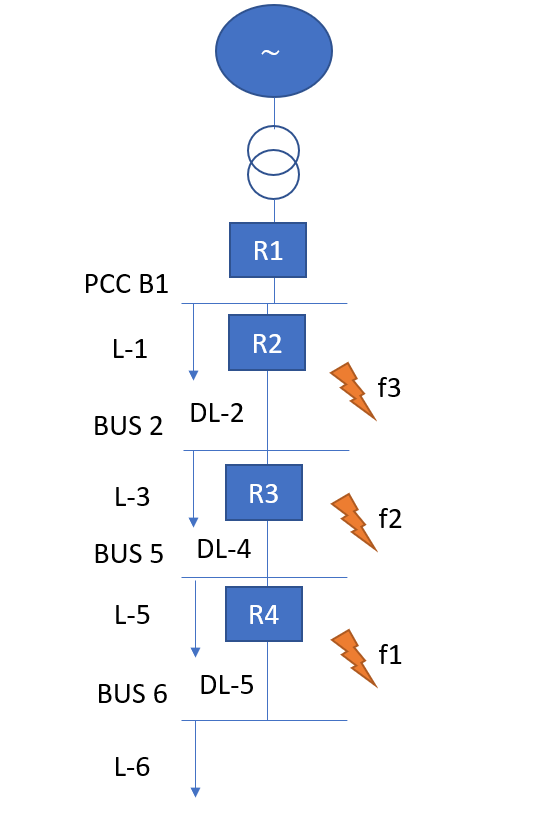

In [ ]:


def create_iec_microgrid():
    # Crear red vacía
    net = pp.create_empty_network(f_hz=60.0)

    # ================= BUSES =================
    # Red de utilidad
    bus_utility = pp.create_bus(net, vn_kv=120.0, name="Utility 120kV")

    # Nivel de distribución 25 kV
    bus_pcc = pp.create_bus(net, vn_kv=25.0, name="PCC B1")
    bus2 = pp.create_bus(net, vn_kv=25.0, name="BUS 2")
    #bus3 = pp.create_bus(net, vn_kv=25.0, name="BUS 3")
    #bus4 = pp.create_bus(net, vn_kv=25.0, name="BUS 4")
    bus5 = pp.create_bus(net, vn_kv=25.0, name="BUS 5")
    bus6 = pp.create_bus(net, vn_kv=25.0, name="BUS 6")

    # Buses de Generadores (Baja Tensión)
    #bus_dg1 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG1")
    #bus_dg2 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG2")
    #bus_dg3 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG3")
    #bus_dg4 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG4")

    # ================= GRID EXTERNO =================
    # S_sc = 1000 MVA según Tabla 1
    pp.create_ext_grid(net, bus_utility, s_sc_max_mva=1000.0, rx_max=0.1, name="Utility Grid")

    # ================= TRANSFORMADORES =================
    # vkr_percent = 0.00375 * 100 = 0.375%
    # vk_percent = sqrt(0.00375^2 + 0.01^2) * 100 = 1.068%
    # Calc: vkr=R1*100 | vk=sqrt(R1**2+X1**2)*100 | pfe=(1/Rm)*Sn*1e3 | i0=sqrt((1/Rm)**2+(1/Xm)**2)*100


    # TR-1: 15 MVA, 120/25 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus_utility, lv_bus=bus_pcc, sn_mva=15.0,
                                          vn_hv_kv=120.0, vn_lv_kv=25.0, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=30, i0_percent=0.2828, name="TR-1")
    """
    # TR-2 y TR-3: 12 MVA, 25/2.4 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus2, lv_bus=bus_dg1, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-2")
    pp.create_transformer_from_parameters(net, hv_bus=bus3, lv_bus=bus_dg2, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-3")

    # TR-4 y TR-5: 10 MVA, 25/0.575 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus4, lv_bus=bus_dg3, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-4")
    pp.create_transformer_from_parameters(net, hv_bus=bus6, lv_bus=bus_dg4, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-5")
    """

    # ================= LÍNEAS DE DISTRIBUCIÓN =================
    # R1 = 0.413 ohm/km, L1 = 3.32e-3 H/km -> X1 = 2*pi*60*3.32e-3 = 1.251 ohm/km
    # C1 = 5.01e-9 F/km
    line_params = {
    "r_ohm_per_km": 0.413,
    "x_ohm_per_km": 1.251,
    "c_nf_per_km": 5.01,
    "r0_ohm_per_km": 0.1153, # Datos de la Tabla 5
    "x0_ohm_per_km": 0.396,  # Calculado de L0
    "c0_nf_per_km": 11.33,   # Datos de la Tabla 5
    "max_i_ka": 1.0
}

    #pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus3, length_km=30.0, name="DL-1", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus2, length_km=30.0, name="DL-2", **line_params)
    #pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus4, length_km=30.0, name="DL-3", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus5, length_km=30.0, name="DL-4", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus5, to_bus=bus6, length_km=30.0, name="DL-5", **line_params)

    # Interruptores de lazo (Loop breakers) - Normalmente abiertos para operación radial
    #pp.create_switch(net, bus=bus2, element=bus4, et="b", closed=False, name="CB_LOOP 1")
    #pp.create_switch(net, bus=bus4, element=bus6, et="b", closed=False, name="CB_LOOP 2")

    # ================= GENERADORES DISTRIBUIDOS =================
    # DG1, DG2: Sincrónicos (9 MVA, xd'' = 0.177)
    #pp.create_gen(net, bus_dg1, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG1")
    #pp.create_gen(net, bus_dg2, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG2")

    # DG3: Inversor Eólico (6 MVA, xd'' = 0.252)
    #pp.create_gen(net, bus_dg3, p_mw=5.4, vm_pu=1.0, sn_mva=6.0, vn_kv=0.575, xdss_pu=0.252, rdss_ohm=0.0, cos_phi=0.9, name="DG3")

    # DG4: DFIG Eólico (9 MVA, Ls + Lr' = 0.34)
    #pp.create_gen(net, bus_dg4, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=0.575, xdss_pu=0.34, rdss_ohm=0.0, cos_phi=0.9, name="DG4")

    # ================= CARGAS =================
    # Total de 22 MW y 10 MVAR dividido en 6 cargas
    p_load = 22.0 / 6.0
    q_load = 10.0 / 6.0

    pp.create_load(net, bus_pcc, p_mw=p_load, q_mvar=q_load, name="L-1")
    pp.create_load(net, bus2, p_mw=p_load, q_mvar=q_load, name="L-2")
    #pp.create_load(net, bus3, p_mw=p_load, q_mvar=q_load, name="L-3")
    #pp.create_load(net, bus4, p_mw=p_load, q_mvar=q_load, name="L-4")
    pp.create_load(net, bus5, p_mw=p_load, q_mvar=q_load, name="L-5")
    pp.create_load(net, bus6, p_mw=p_load, q_mvar=q_load, name="L-6")

    return net

# Inicializar red
net = create_iec_microgrid()

# ================= ANÁLISIS DE CORTOCIRCUITO =================
# Ejecutar cortocircuito trifásico según norma IEC 60909
# case="max" para calcular corrientes máximas de falla
sc.calc_sc(net, case="max", ip=True, ith=True, branch_results=True)

# Imprimir resultados en buses (corriente de cortocircuito subtransitoria ikss)
print("--- Resultados de Cortocircuito en Buses (ikss en kA) ---")
print(net.res_bus_sc[['ikss_ka', 'ip_ka']])

--- Resultados de Cortocircuito en Buses (ikss en kA) ---
     ikss_ka      ip_ka
0   4.811252  11.880038
1  13.921352  30.463729
2   0.390529   0.766535
3   0.198024   0.388142
4   0.132641   0.259863


/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


In [ ]:
net.bus

,name,vn_kv,type,zone,in_service,geo
0,Utility 120kV,120.0,b,None,True,None
1,PCC B1,25.0,b,None,True,None
2,BUS 2,25.0,b,None,True,None
3,BUS 5,25.0,b,None,True,None
4,BUS 6,25.0,b,None,True,None


In [ ]:
#ICC = ICC4.copy()

#columns: main
#rows: back ups
   #R7,R6,R4,R2
#R7
#R6
#R4
#R2
BACKUP = [[0,0,0,0],#R1
          [1,0,0,0],#R2
          [1,1,0,0],#R3
          [1,1,1,0]]#R4

#R7
#R6
#R4
#R2
CT_PS = [[800,0.5],#[[1200,1],#1
          [400,0.5],#6
          [400,0.5],#4
          [400,0.5]]#2

# faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2", "F4":"DL-1", "F5":"DL-3"}
#             7,6,4,2
#             1,2,3,4
principal = [[0,0,0,1],
              [0,0,1,0],
              [0,1,0,0]]

faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2"}

In [ ]:
headers = ["DG0", "DG1", "DG2", "DG3","DG4"]
rows = ["OM1","OM2","OM3","OM4"]

matrix = [[1,0,0,0,0],
          [1,1,1,1,1],
          [1,1,1,0,0],
          [0,1,1,1,1]]

OMS = {
    (rows[i], headers[j]): matrix[i][j]
    for i in range(len(rows))
    for j in range(len(headers))
}



In [ ]:

Cindex={"STI":{"A":0.05,"B":0.04,"C":0},
        "SI":{"A":0.14,"B":0.02,"C":0}}
        # "VI":{"A":13.5,"B":1,"C":0},
        # "EI":{"A":80,"B":2,"C":0},
        # "LTI":{"A":120,"B":1,"C":0},
        # "UI":{"A":315.2,"B":2.5,"C":0},
        # "IEEE-LTI":{"A":0.086,"B":0.05,"C":0.185},
        # "IEEE-LTVI":{"A":28.55,"B":2,"C":0.712},
        # "IEEE-LTEI":{"A":64.07,"B":2,"C":0.25},
        # "IEEE-MI":{"A":0.0515,"B":0.02,"C":0.114},
        # "IEEE-VI":{"A":19.61,"B":2,"C":0.491},
        # "IEEE-EI":{"A":28.2,"B":2,"C":0.1217},
        # "IEEE-STI":{"A":0.16758,"B":0.02,"C":0.11858},
        # "IEEE-STEI":{"A":1.281,"B":2,"C":0.005}}
C=["STI", "SI"]#, "VI","EI","LTI","IEEE-LTI","IEEE-LTVI","IEEE-LTEI","IEEE-MI","IEEE-VI","IEEE-EI","IEEE-STI","IEEE-STEI"]


# Function calculate_sc_percentage

In [ ]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g0_us_per_km
0,DL-2,None,1,2,30.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0
1,DL-4,None,2,3,30.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0
2,DL-5,None,3,4,30.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0


In [ ]:
def calculate_sc_percentage(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)

        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        # resultados.append({
        #     "Porcentaje": f"{int(porcentaje*100)}%",
        #     "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
        #     "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
        #     "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        # })
        resultados.append(net.res_line_sc.ikss_ka.at[bus_inicial]*1000)

        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    #return pd.DataFrame(resultados)
    return resultados



# Beta equation

$$
 \beta_{ficd} = \frac{A_c}{(\frac{ICC_{ifd}}{Ipickup_i})^{B_c}-1}
$$

In [ ]:
Findex=[f"F{i+1}" for i in range(3)]
Rindex=[f"R{i+1}" for i in range(4)]

BETA=dict()
B=dict()

for relay in range(len(Rindex)):
  for fault in range(len(Findex)):
    for curve in range(len(C)):
      dsteps = 3
      steps = [i / dsteps for i in range(1, dsteps)]
      ICC_fid = calculate_sc_percentage(net, nombre_linea=faults[Findex[fault]], pasos=dsteps)
      for index, ICC2 in enumerate(ICC_fid):
        #PSMif=(ICC[fault][relay])/(CT_PS[relay][0])/CT_PS[relay][1]
        PSMif=(ICC2)/(CT_PS[relay][0])/CT_PS[relay][1]
        #BETA[Findex[fault],Rindex[relay],C[curve]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)
        BETA[Findex[fault],Rindex[relay],C[curve],steps[index]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)

for main in range(len(Rindex)):
  for backup in range(len(Rindex)):
    B[Rindex[main],Rindex[backup]] = BACKUP[main][backup]


In [ ]:
# Convert the BETA dictionary to a list of dictionaries for DataFrame creation
beta_data = []
for key, value in BETA.items():
    falla, rele, curva, distancia = key
    beta_data.append({
        'Falla': falla,
        'Rele': rele,
        'Curva': curva,
        'Distancia': distancia,
        'Beta': value
    })

# Create the DataFrame
beta_df = pd.DataFrame(beta_data)

# Display the first few rows of the DataFrame
display(beta_df.head())


,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.333333,-1.486782
1,F1,R1,STI,0.666667,-1.291350
2,F1,R1,SI,0.333333,-8.255381
3,F1,R1,SI,0.666667,-7.160870
4,F2,R1,STI,0.333333,-0.050000


In [ ]:
beta_df[beta_df["Rele"]=="R2"]

,Falla,Rele,Curva,Distancia,Beta
12,F1,R2,STI,0.333333,-7.738371
13,F1,R2,STI,0.666667,-4.275740
14,F1,R2,SI,0.333333,-43.264763
15,F1,R2,SI,0.666667,-23.873940
16,F2,R2,STI,0.333333,-0.050000
17,F2,R2,STI,0.666667,-0.050000
18,F2,R2,SI,0.333333,-0.140000
19,F2,R2,SI,0.666667,-0.140000
20,F3,R2,STI,0.333333,-0.050000
21,F3,R2,STI,0.666667,-0.050000


In [ ]:
beta_df[beta_df["Beta"]>0]

,Falla,Rele,Curva,Distancia,Beta


In [ ]:
calculate_sc_percentage(net, nombre_linea="DL-5", pasos=dsteps)

[np.float64(170.07857573290852), np.float64(149.0448922850012)]

In [ ]:
steps

[0.3333333333333333, 0.6666666666666666]